# 6. Threshold Tuning

## Purpose
Find the optimal classification threshold for converting predicted
probabilities into class labels. 

This notebook is skipped automatically for regression problems.

## Inputs
- `data/processed/` — final preprocessed training data
- `config.yaml` — threshold metric and number of thresholds
- `artifacts/baseline_trainer.pkl` — for task type detection
- `artifacts/tuned_models.pkl` — tuned models from notebook 5

## Outputs
- `artifacts/threshold.pkl` — optimal threshold and associated metadata
- `reports/figures/threshold_tuning.png` — metrics vs threshold plot
- `reports/figures/threshold_tuning_annotated.png` — annotated plot
  showing optimal threshold location

## Decisions for the user
- Set `threshold_tuning.metric` in `config.yaml` based on the business
  problem:
  - `f1` — balanced precision and recall, good default for most problems
  - `recall` — minimise false negatives, use when missing a positive is
    costly e.g. medical diagnosis, fraud detection, churn prediction
  - `precision` — minimise false positives, use when false alarms are
    costly e.g. spam detection, ad targeting
  - `accuracy` — use only when classes are perfectly balanced

## Important note
Threshold tuning is performed on training data only. The optimal threshold
is validated on the held out test set in notebook 7 where both default
and optimal threshold results are compared side by side.

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from src.config.settings import load_config
from src.config.paths import (
    PROCESSED_DATA_DIR,
    ARTIFACTS_DIR,
    TUNED_MODELS_DIR
)
from src.data.load_data import load_raw_data
from src.models.training.threshold_tuning import tune_threshold, compute_threshold_curves

## 1. Load config

In [2]:
config = load_config()

TARGET = config["target"]
DROP_COLS = config["drop_columns"]
SPLIT_CONFIG = config["split"]
TUNING_CONFIG = config["tuning"]
THRESHOLD_CONFIG = config["threshold_tuning"]

print(f"Target:           {TARGET}")
print(f"Optimising for:   {THRESHOLD_CONFIG['metric']}")

Target:           Survived
Optimising for:   f1


## 2. Load processed data

In [3]:
X_train = pd.read_csv(PROCESSED_DATA_DIR / "X_train.csv")
X_test = pd.read_csv(PROCESSED_DATA_DIR / "X_test.csv")
y_train = pd.read_csv(PROCESSED_DATA_DIR / "y_train.csv").squeeze()
y_test = pd.read_csv(PROCESSED_DATA_DIR / "y_test.csv").squeeze()

print(f"X_train shape: {X_train.shape}")

X_train shape: (712, 57)


## 3. Check task type
Threshold tuning only applies to classification problems. This cell
confirms the task type and exits for regression problems.

In [4]:
baseline_trainer = joblib.load(ARTIFACTS_DIR / "baseline_trainer.pkl")
task = baseline_trainer.task_

print(f"Task: {task}")

# Skip threshold tuning for regression

if task == "regression":
    print("Threshold tuning is not applicable for regression problems.")
    print("Proceeding to final evaluation.")
else:
    print("Classification task detected — proceeding with threshold tuning.")


Task: classification
Classification task detected — proceeding with threshold tuning.


## 4. Load tuned models

In [5]:
tuned_models = joblib.load(ARTIFACTS_DIR / "tuned_models.pkl")

print(f"Available tuned models: {list(tuned_models.keys())}")

# %%
# 5. Select Model to Tune Threshold For
# Use first model in models_to_tune list
model_name = TUNING_CONFIG["models_to_tune"][0]
model = tuned_models[model_name]

print(f"Tuning threshold for: {model_name}")

Available tuned models: ['xgboost_classifier']
Tuning threshold for: xgboost_classifier


## 5. Select model
The first model from `tuning.models_to_tune` in `config.yaml` is used
for threshold tuning. This should be the same model taken forward to
final evaluation.

In [6]:
model_name = TUNING_CONFIG["models_to_tune"][0]
model = tuned_models[model_name]

print(f"Tuning threshold for: {model_name}")

Tuning threshold for: xgboost_classifier


## 6. Get training predictions
Predicted probabilities are computed on the training set for threshold
optimisation. CatBoost uses raw data, all other models use preprocessed
data.

In [7]:
if "catboost" in model_name:
    from sklearn.model_selection import train_test_split
    from src.models.training.trainer import ModelTrainer

    df = load_raw_data()
    X_raw = df.drop(columns=[TARGET] + DROP_COLS)
    y_all = df[TARGET]

    stratify_col = y_all if SPLIT_CONFIG["stratify"] else None
    X_train_raw, X_test_raw, _, _ = train_test_split(
        X_raw, y_all,
        test_size=SPLIT_CONFIG["test_size"],
        random_state=SPLIT_CONFIG["random_state"],
        stratify=stratify_col
    )
    trainer_helper = ModelTrainer()
    X_train_input = trainer_helper._prepare_catboost_data(X_train_raw)
else:
    X_train_input = X_train

y_proba_train = model.predict_proba(X_train_input)[:, 1]

print(f"Probability predictions computed — shape: {y_proba_train.shape}")

Probability predictions computed — shape: (712,)


## 7. Compute threshold curves
Precision, recall, F1 and accuracy are computed across all threshold
values. These curves are used to visualise the precision-recall tradeoff
and identify the optimal threshold.

In [8]:
curves = compute_threshold_curves(
    y_train.values,
    y_proba_train,
    num_thresholds=THRESHOLD_CONFIG["num_thresholds"]
)

curves.head()

,threshold,precision,recall,f1,accuracy
0,0.00,0.383427,1.0,0.554315,0.383427
1,0.01,0.383427,1.0,0.554315,0.383427
2,0.02,0.383427,1.0,0.554315,0.383427
3,0.03,0.383427,1.0,0.554315,0.383427
4,0.04,0.388889,1.0,0.560000,0.397472


## 8. Plot precision-recall tradeoff
The left plot shows how each metric changes as the threshold varies.
The right plot shows the precision-recall curve.

Use these plots to understand the impact of threshold choice before
committing to a value in config.

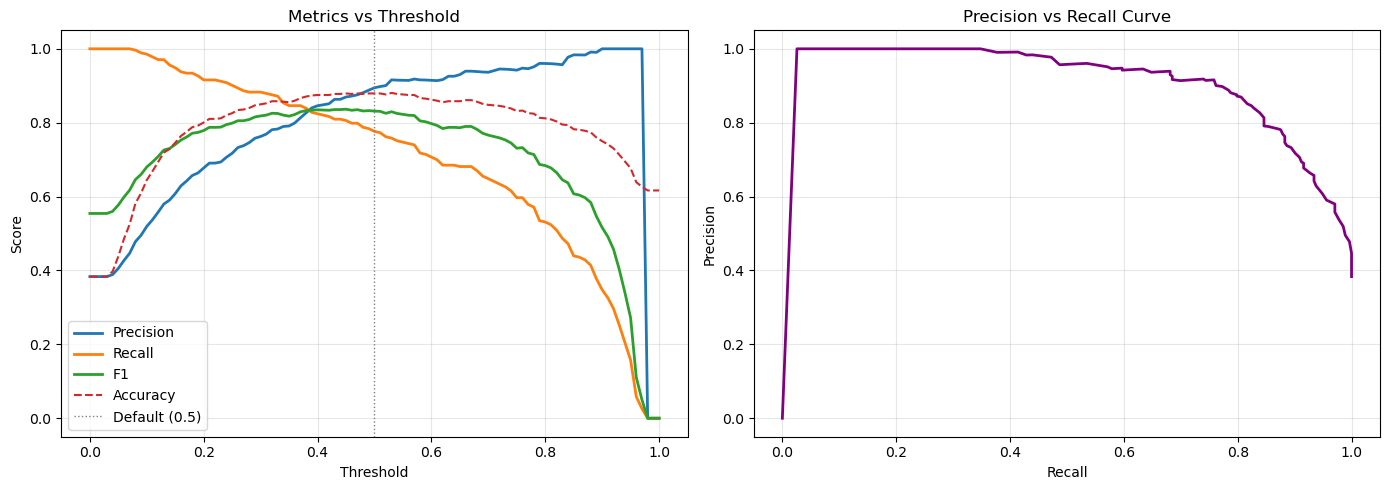

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot — all metrics vs threshold
axes[0].plot(curves["threshold"], curves["precision"], label="Precision", linewidth=2)
axes[0].plot(curves["threshold"], curves["recall"], label="Recall", linewidth=2)
axes[0].plot(curves["threshold"], curves["f1"], label="F1", linewidth=2)
axes[0].plot(curves["threshold"], curves["accuracy"], label="Accuracy",
             linewidth=1.5, linestyle="--")
axes[0].axvline(x=0.5, color="gray", linestyle=":", linewidth=1, label="Default (0.5)")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Metrics vs Threshold")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right plot — precision vs recall curve
axes[1].plot(curves["recall"], curves["precision"], linewidth=2, color="purple")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision vs Recall Curve")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("reports/figures/threshold_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Find optimal threshold
Searches all threshold values and selects the one that maximises the
configured metric. Compares performance at the default threshold (0.5)
vs the optimal threshold.

In [10]:
result = tune_threshold(
    y_true=y_train.values,
    y_proba=y_proba_train,
    metric_name=THRESHOLD_CONFIG["metric"],
    num_thresholds=THRESHOLD_CONFIG["num_thresholds"],
)

print(f"\nOptimal threshold:  {result['best_threshold']:.4f}")
print(f"Best {result['metric']} score: {result['best_score']:.4f}")
print(f"\nDefault threshold (0.5):")

default_pred = (y_proba_train >= 0.5).astype(int)
from sklearn.metrics import f1_score, precision_score, recall_score
print(f"  F1:        {f1_score(y_train.values, default_pred):.4f}")
print(f"  Precision: {precision_score(y_train.values, default_pred):.4f}")
print(f"  Recall:    {recall_score(y_train.values, default_pred):.4f}")

print(f"\nOptimal threshold ({result['best_threshold']:.4f}):")
optimal_pred = (y_proba_train >= result["best_threshold"]).astype(int)
print(f"  F1:        {f1_score(y_train.values, optimal_pred):.4f}")
print(f"  Precision: {precision_score(y_train.values, optimal_pred):.4f}")
print(f"  Recall:    {recall_score(y_train.values, optimal_pred):.4f}")


Optimal threshold:  0.4500
Best f1 score: 0.8365

Default threshold (0.5):
  F1:        0.8314
  Precision: 0.8945
  Recall:    0.7766

Optimal threshold (0.4500):
  F1:        0.8365
  Precision: 0.8696
  Recall:    0.8059


## 10. Annotated plot
Redraws the plots with the optimal threshold marked so its position
on both curves is clearly visible.

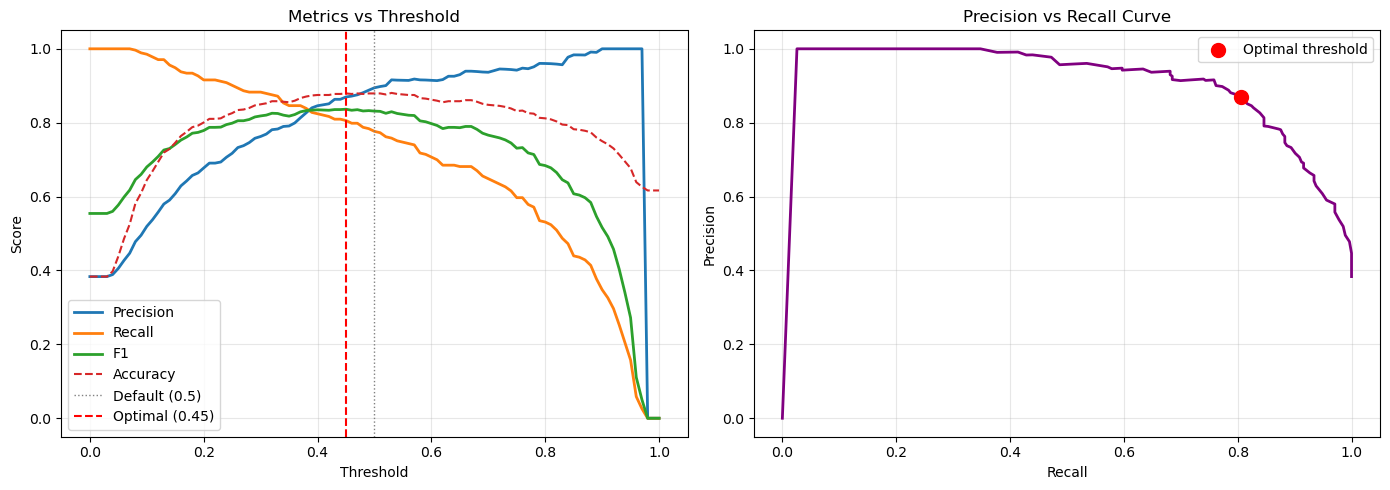

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(curves["threshold"], curves["precision"], label="Precision", linewidth=2)
axes[0].plot(curves["threshold"], curves["recall"], label="Recall", linewidth=2)
axes[0].plot(curves["threshold"], curves["f1"], label="F1", linewidth=2)
axes[0].plot(curves["threshold"], curves["accuracy"], label="Accuracy",
             linewidth=1.5, linestyle="--")
axes[0].axvline(x=0.5, color="gray", linestyle=":", linewidth=1, label="Default (0.5)")
axes[0].axvline(x=result["best_threshold"], color="red", linestyle="--",
                linewidth=1.5, label=f"Optimal ({result['best_threshold']:.2f})")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Metrics vs Threshold")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(curves["recall"], curves["precision"], linewidth=2, color="purple")
axes[1].scatter(
    [curves.loc[curves["threshold"] == round(result["best_threshold"], 4), "recall"].values[0]],
    [curves.loc[curves["threshold"] == round(result["best_threshold"], 4), "precision"].values[0]],
    color="red", s=100, zorder=5, label=f"Optimal threshold"
)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision vs Recall Curve")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("reports/figures/threshold_tuning_annotated.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Save optimal threshold
The optimal threshold is saved to `artifacts/` for use in the final
evaluation notebook. Both default and optimal threshold results will
be compared on the held out test set in notebook 7.

In [12]:
threshold_artifact = {
    "model_name": model_name,
    "optimal_threshold": result["best_threshold"],
    "metric": result["metric"],
    "best_score": result["best_score"],
}

joblib.dump(threshold_artifact, ARTIFACTS_DIR / "threshold.pkl")
print(f"Optimal threshold saved to {ARTIFACTS_DIR / 'threshold.pkl'}")
print(f"\nThreshold artifact: {threshold_artifact}")

Optimal threshold saved to C:\ML\ML Workflow\Projects\Project Name Template\artifacts\threshold.pkl

Threshold artifact: {'model_name': 'xgboost_classifier', 'optimal_threshold': 0.45, 'metric': 'f1', 'best_score': 0.8365019011406845}
